In [28]:
import keras
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

C:\Users\Patrik\anaconda3\envs\keras\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
"""
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)
"""

# Normalizing
x_train=x_train/255
x_test=x_test/255

#One hot encoding
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [4]:

model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
    ])


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [10]:
history = model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3187 - loss: 1.9173 - val_accuracy: 0.3599 - val_loss: 1.8037
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3842 - loss: 1.7347 - val_accuracy: 0.3943 - val_loss: 1.7145
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4105 - loss: 1.6627 - val_accuracy: 0.3965 - val_loss: 1.7086
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4233 - loss: 1.6195 - val_accuracy: 0.4322 - val_loss: 1.6177
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4352 - loss: 1.5897 - val_accuracy: 0.4345 - val_loss: 1.6009
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4465 - loss: 1.5590 - val_accuracy: 0.4369 - val_loss: 1.5972
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4570 - loss: 1.5332 - val_accuracy: 0.4303 - val_loss: 1.6014
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4596 - loss: 1.5163 - val_acc

In [12]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 3ms/step - accuracy: 0.4443 - loss: 1.5758
Test loss: 1.5758086442947388
Test accuracy: 0.44429999589920044


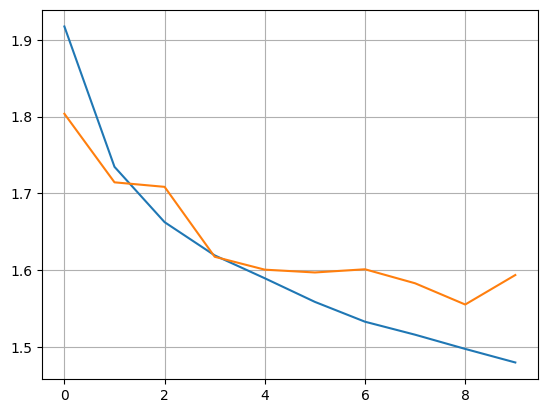

In [11]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

In [15]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
    ])


In [16]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [17]:
history = model.fit(x_train, y_train, batch_size=64, epochs=50, validation_split=0.2, verbose=0)

In [18]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 4ms/step - accuracy: 0.4925 - loss: 1.4319
Test loss: 1.431902289390564
Test accuracy: 0.4925000071525574


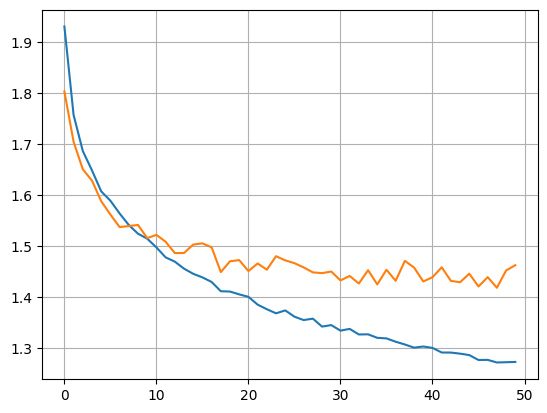

In [19]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

In [55]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(10, activation='softmax')
    ])

In [56]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [57]:

early_stopping = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(x_train, y_train, epochs=500, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3004 - loss: 1.9532 - val_accuracy: 0.3574 - val_loss: 1.8114
Epoch 2/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3620 - loss: 1.7837 - val_accuracy: 0.3561 - val_loss: 1.7832
Epoch 3/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3843 - loss: 1.7198 - val_accuracy: 0.3900 - val_loss: 1.7057
Epoch 4/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4049 - loss: 1.6650 - val_accuracy: 0.3822 - val_loss: 1.7334
Epoch 5/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4164 - loss: 1.6345 - val_accuracy: 0.4240 - val_loss: 1.6151
Epoch 6/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4272 - loss: 1.5967 - val_accuracy: 0.4224 - val_loss: 1.6249
Epoch 7/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4332 - loss: 1.5761 - val_accuracy: 0.4420 - val_loss: 1.5542
Epoch 8/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4438 - loss: 1.5567 -

In [58]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 4ms/step - accuracy: 0.5027 - loss: 1.4053
Test loss: 1.4053443670272827
Test accuracy: 0.5026999711990356


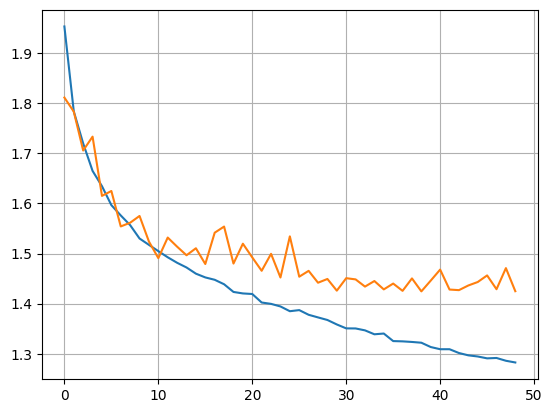

In [59]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()


0 	airplane  
1 	automobile  
2 	bird  
3 	cat  
4 	deer  
5 	dog  
6 	frog  
7 	horse  
8 	ship  
9 	truck  


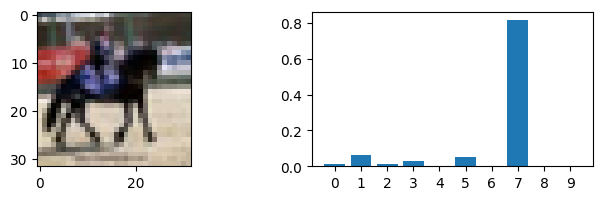

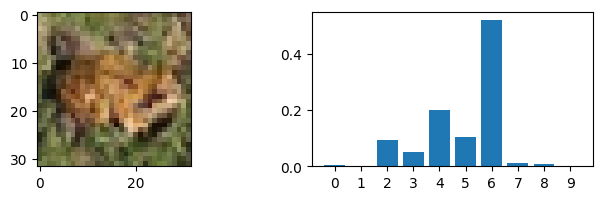

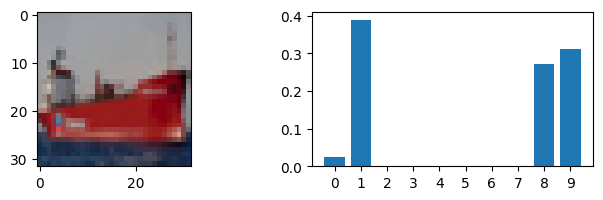

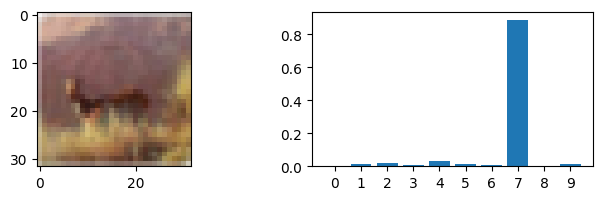

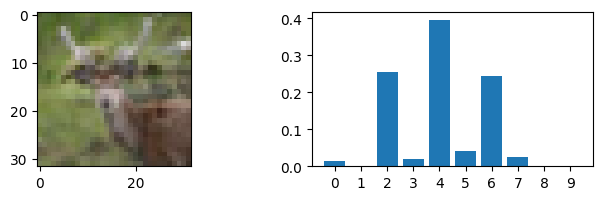

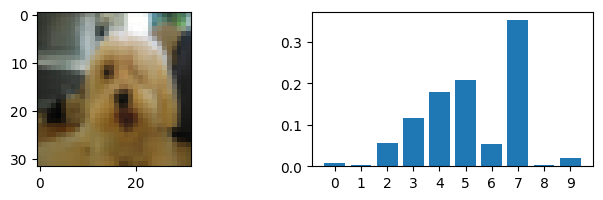

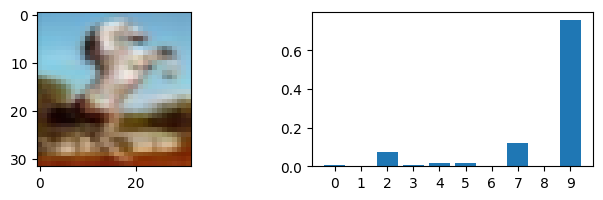

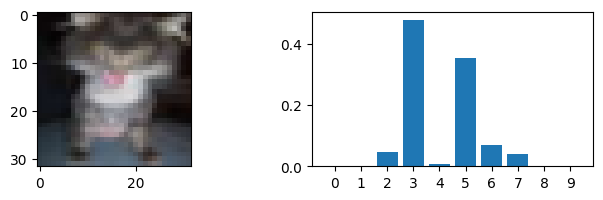

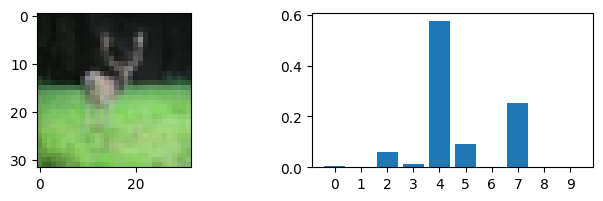

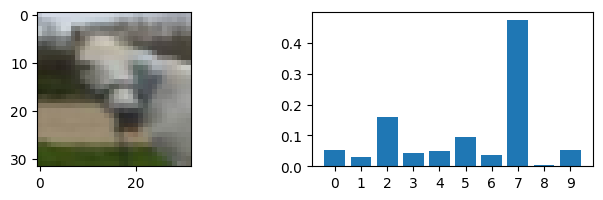

In [60]:
x = x_test
y = model(x)
start = 5000

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k].reshape((32, 32, 3)))
    ind = np.arange(0, 10)
    plt.subplot(1,2,2)
    plt.bar(ind, y[start+k].numpy().flatten())
    plt.xticks(range(10))